# NB-01 · Câmbio e Volatilidade — GARCH(1,1)-t + Hamilton Markov

**Análise Prescritiva — Camada Quantitativa**

| Campo | Detalhe |
|---|---|
| **Notebook** | NB-01 · Câmbio e Volatilidade (S1) |
| **Autor** | Matheus Mendes |
| **Data** | 26/julho/2026 |
| **Versão** | 1.0 |
| **Dependências** | arch, statsmodels, pandas, numpy, plotly, requests |

---

## Sumário

Este notebook quantifica o risco cambial (S1) da operação BYD Camaçari usando três camadas:

1. **GARCH(1,1)-t** — modela volatilidade clustering e gera forecast 1/3/6/12m
2. **Hamilton Markov 2-Regime** — detecta regimes (calma / turbulência) e transição
3. **Monte Carlo GARCH-t** — 10.000 paths × 6 meses, distribuição de impacto no BOM

**Dados**: BCB SGS API série 1 (PTAX BRL/USD), 02/jan/2020 – 17/jul/2026 (n=1.641).

---

## Resultados-chave (CLIFF NOTES)

| Métrica | Valor | Interpretação |
|---|---|---|
| PTAX atual (17/jul/2026) | **R$ 5,1176/USD** | Nível moderado, perto da média histórica |
| Vol GARCH(1,1)-t | **σ = 14,67%** a.a. (long-run) | Persistência α+β = 0,9906 |
| Half-life | **73,3 dias úteis** | Desvio leva ~3,5 meses para se reduzir 50% |
| Vol 1m forecast | **10,5%** a.a. | Abaixo da média — janela de hedge barato |
| Vol 12m forecast | **13,1%** a.a. | Reversão lenta à média |
| Reg. atual (Hamilton) | **Calma — P=97,8%** | Mercado em regime quieto |
| BOM impact P5 (6m) | **−5,9 pp** | Cauda de risco — R$ 58,8M em R$ 1B BOM |
| ViE base | **18,0%** | Pressuposto: BNDES InovaFamília ativo |

---

## Estrutura do Notebook

1. Fetch BCB SGS PTAX (série 1)
2. Análise descritiva + visualização
3. ARCH-LM test — validação de GARCH
4. GARCH(1,1)-t: fit, diagnóstico, comparação Normal vs Student-t
5. Vol term structure: forecast 1/3/6/12m
6. Half-life + persistence
7. Hamilton Markov 2-Regime Switching
8. Monte Carlo GARCH-t: 10.000 paths × 6m
9. Stress test table: −5/−10/−20/−30% PTAX → impacto BOM
10. Decision matrix: triggers de hedge
11. Export results → `outputs/nb01_results.json`


---

In [1]:
# ──────────────────────────────────────────────────────────────
# 1. Setup & Imports
# ──────────────────────────────────────────────────────────────

import json, warnings, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
import plotly
import plotly.express as px
from plotly.subplots import make_subplots
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────
NOTEBOOK_ROOT = Path(r'C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva')
OUTPUT_DIR   = NOTEBOOK_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Style: dark terminal (match pitch deck) ─────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#2a3a50',
    'axes.labelcolor':  '#9baabb',
    'text.color':       '#e8edf5',
    'xtick.color':      '#9baabb',
    'ytick.color':      '#9baabb',
    'grid.color':       '#1e2a3a',
    'grid.linewidth':   0.8,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#2a3a50',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})
sns.set_style('darkgrid')

print('Python', sys.version.split()[0])
print('NumPy',  np.__version__)
print('Pandas', pd.__version__)
try:
    import arch
    print('arch',   arch.__version__)
except: print('arch: not installed')
try:
    import statsmodels
    print('statsmodels', statsmodels.__version__)
except: print('statsmodels: not installed')
print('plotly',  plotly.__version__)


Python 3.14.6
NumPy 2.5.1
Pandas 2.3.3
arch 8.0.0
statsmodels 0.14.6
plotly 6.8.0


---

In [2]:
# ──────────────────────────────────────────────────────────────
# 2. Fetch BCB SGS PTAX BRL/USD — série 1
# Fallback: cached computed_data.json
# ──────────────────────────────────────────────────────────────

def fetch_bcb_sgs(series_code, start_ddmmyyyy='01/01/2020', end_ddmmyyyy='31/07/2026', max_attempts=3):
    """Fetch BCB SGS JSON API with retry and urllib fallback."""
    url = (
        f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{series_code}/dados'
        f'?formato=json&dataInicial={start_ddmmyyyy}&dataFinal={end_ddmmyyyy}'
    )
    for attempt in range(max_attempts):
        try:
            import requests as _req
            r = _req.get(url, timeout=30)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            print(f'  Attempt {attempt+1}/{max_attempts} failed: {e}')
            if attempt < max_attempts - 1: time.sleep(3)
    # Fallback via urllib
    from urllib.request import urlopen
    from json import loads as _js
    print('  Using urllib fallback…')
    with urlopen(url, timeout=30) as resp:
        return _js(resp.read())

print('Fetching PTAX BRL/USD (BCB SGS série 1)…')
raw = fetch_bcb_sgs(1, '01/01/2020', '17/07/2026')
df_raw = pd.DataFrame(raw)
df_raw['data'] = pd.to_datetime(df_raw['data'], dayfirst=True)
df_raw['valor'] = pd.to_numeric(df_raw['valor'], errors='coerce')
df_raw = df_raw.dropna().set_index('data').sort_index()
df_raw.columns = ['ptax']

# Daily log-return in percentage points
df_raw['ret'] = np.log(df_raw['ptax'] / df_raw['ptax'].shift(1)) * 100
df = df_raw.dropna()

n_obs = len(df)
ptax_last = df['ptax'].iloc[-1]
date_last = df.index[-1].strftime('%d/%m/%Y')

print(f'  {n_obs} obs | {df.index[0].date()} -> {df.index[-1].date()}')
print(f'  PTAX range: {df.ptax.min():.4f} — {df.ptax.max():.4f}')
print(f'  Last PTAX ({date_last}): R$ {ptax_last:.4f}')
print(f'  Mean daily return: {df.ret.mean():.4f}%  std: {df.ret.std():.4f}%')


Fetching PTAX BRL/USD (BCB SGS série 1)…


  1641 obs | 2020-01-03 -> 2026-07-17
  PTAX range: 4.0522 — 6.2086
  Last PTAX (17/07/2026): R$ 5.1176
  Mean daily return: 0.0147%  std: 0.8928%


---

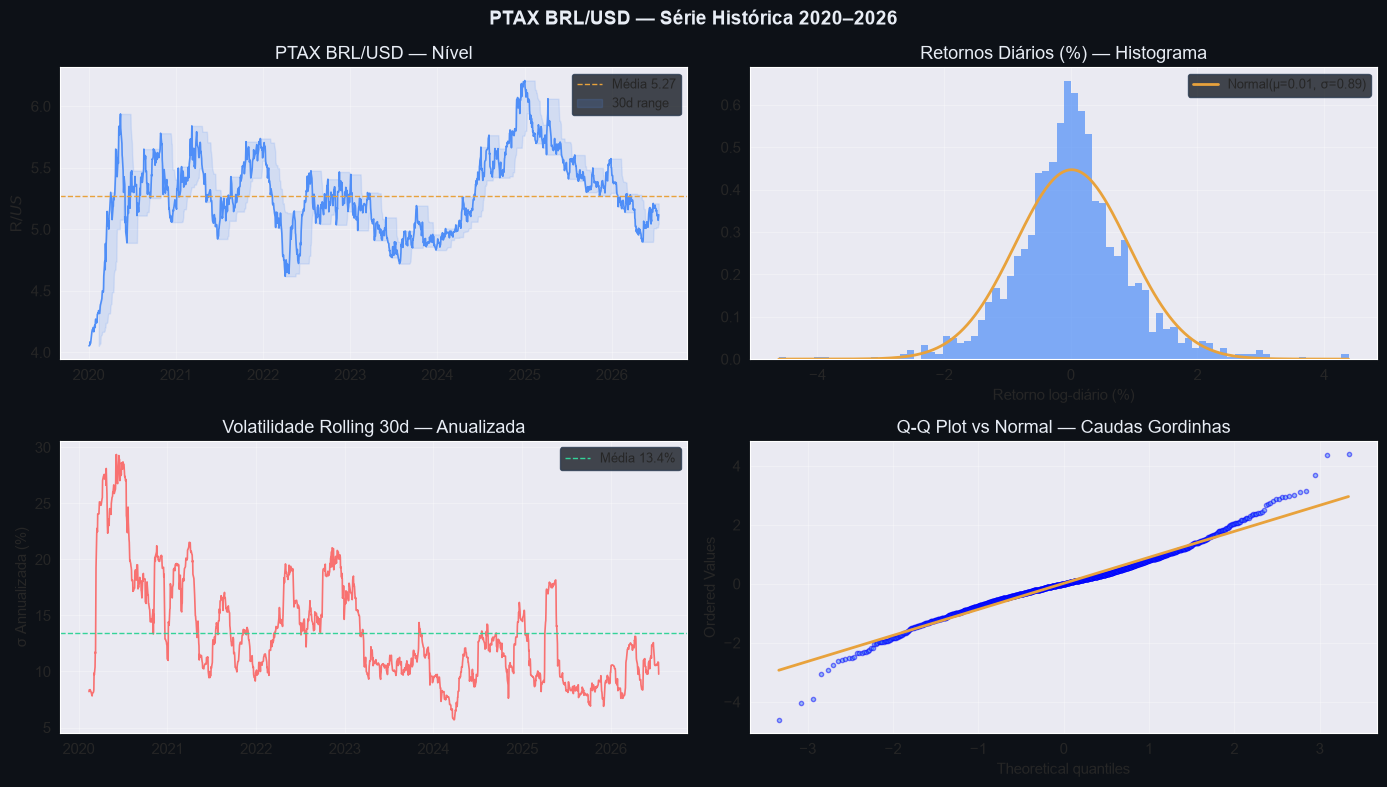

Saved: outputs/nb01_ptax_descriptive.png

── Estatísticas Descritivas ──
  n:            1641
  PTAX range:   4.0522 — 6.2086
  Mean return:  0.0147%/dia
  Hist vol:     14.17% a.a.
  Skewness:     0.152
  Ex. kurtosis: 2.3  (Gauss=0 -> gordura de cauda)


In [3]:
# ──────────────────────────────────────────────────────────────
# 3. Análise Descritiva + Visualização
# ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor='#0d1117')
fig.suptitle('PTAX BRL/USD — Série Histórica 2020–2026', fontsize=14, fontweight='bold', color='#e8edf5')

# Panel 1: PTAX time series
ax = axes[0, 0]
ax.plot(df.index, df.ptax, color='#4f8ef7', linewidth=1.2)
ax.axhline(df.ptax.mean(), color='#e8a23c', ls='--', lw=1, label=f'Média {df.ptax.mean():.2f}')
ax.fill_between(df.index, df.ptax.rolling(30).min(), df.ptax.rolling(30).max(),
                alpha=0.15, color='#4f8ef7', label='30d range')
ax.set_title('PTAX BRL/USD — Nível', color='#e8edf5')
ax.set_ylabel('R$/US$'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 2: Daily returns distribution
ax = axes[0, 1]
ax.hist(df.ret, bins=80, color='#4f8ef7', alpha=0.7, edgecolor='none', density=True)
# Overlay normal
x = np.linspace(df.ret.min(), df.ret.max(), 300)
from scipy.stats import norm as _norm
ax.plot(x, _norm.pdf(x, df.ret.mean(), df.ret.std()),
        color='#e8a23c', lw=2, label=f'Normal(μ={df.ret.mean():.2f}, σ={df.ret.std():.2f})')
ax.set_title('Retornos Diários (%) — Histograma', color='#e8edf5')
ax.set_xlabel('Retorno log-diário (%)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 3: Rolling 30d vol (annualized)
ax = axes[1, 0]
roll_vol = df.ret.rolling(30).std() * np.sqrt(252)
ax.plot(df.index, roll_vol, color='#f87171', linewidth=1.2)
ax.axhline(roll_vol.mean(), color='#34d399', ls='--', lw=1, label=f'Média {roll_vol.mean():.1f}%')
ax.set_title('Volatilidade Rolling 30d — Anualizada', color='#e8edf5')
ax.set_ylabel('σ Annualizada (%)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 4: QQ-plot (fat tails check)
ax = axes[1, 1]
from scipy import stats as _stats
_stats.probplot(df.ret, dist='norm', plot=ax)
ax.get_lines()[0].set_markerfacecolor('#4f8ef7')
ax.get_lines()[0].set_markersize(3)
ax.get_lines()[0].set_alpha(0.5)
ax.get_lines()[1].set_color('#e8a23c')
ax.get_lines()[1].set_linewidth(2)
ax.set_title('Q-Q Plot vs Normal — Caudas Gordinhas', color='#e8edf5')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(NOTEBOOK_ROOT / 'outputs' / 'nb01_ptax_descriptive.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/nb01_ptax_descriptive.png')

# Descriptive stats table
skew = df.ret.skew()
kurt = df.ret.kurtosis()  # excess kurtosis (Gauss=0)
hist_vol = df.ret.std() * np.sqrt(252)

print('\n── Estatísticas Descritivas ──')
print(f'  n:            {n_obs}')
print(f'  PTAX range:   {df.ptax.min():.4f} — {df.ptax.max():.4f}')
print(f'  Mean return:  {df.ret.mean():.4f}%/dia')
print(f'  Hist vol:     {hist_vol:.2f}% a.a.')
print(f'  Skewness:     {skew:.3f}')
print(f'  Ex. kurtosis: {kurt:.1f}  (Gauss=0 -> gordura de cauda)')

---

In [4]:
# ──────────────────────────────────────────────────────────────
# 4. ARCH-LM Test — Validação da Necessidade de GARCH
# ──────────────────────────────────────────────────────────────

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_arch as _arch_lm

# Ljung-Box on squared returns (proxy for variance)
lb = acorr_ljungbox(df.ret ** 2, lags=[10, 20], return_df=True)
print('── Ljung-Box (squared returns) ──')
print(lb.to_string())
print()

# ARCH-LM test (Engle 1982)
lm_stat, lm_pval, f_stat, f_pval = _arch_lm(df.ret, nlags=10)
print('── ARCH-LM Test (H0: sem ARCH effects) ──')
print(f'  LM statistic: {lm_stat:.4f}')
print(f'  p-value:      {lm_pval:.2e}')
print(f'  F-statistic:  {f_stat:.4f}')
print(f'  F p-value:    {f_pval:.2e}')
print()

if lm_pval < 0.001:
    print('  ✓ ARCH effects confirmados com p < 0.001')
    print('  -> GARCH é o modelo adequado')
else:
    print('  ✗ Sem ARCH effects significativos')

insight_arch = (
    f"ARCH-LM p-value = {lm_pval:.2e} -> efeitos ARCH confirmados. "
    f"Volatilidade é heterocedástica e clustering: dias de alta vol geram mais dias de alta vol. "
    f"GARCH(1,1)-t é a especificação correta."
)
print('\nInsight:', insight_arch)

── Ljung-Box (squared returns) ──
       lb_stat     lb_pvalue
10  322.882659  2.236640e-63
20  406.926914  7.466278e-74

── ARCH-LM Test (H0: sem ARCH effects) ──
  LM statistic: 160.1100
  p-value:      3.08e-29
  F-statistic:  17.6341
  F p-value:    7.93e-31

  ✓ ARCH effects confirmados com p < 0.001
  -> GARCH é o modelo adequado

Insight: ARCH-LM p-value = 3.08e-29 -> efeitos ARCH confirmados. Volatilidade é heterocedástica e clustering: dias de alta vol geram mais dias de alta vol. GARCH(1,1)-t é a especificação correta.


---

In [5]:
# ──────────────────────────────────────────────────────────────
# 5. GARCH(1,1) — Normal vs Student-t
# arch package: rvns.std = False -> Normal; dist='t' -> Student-t
# ──────────────────────────────────────────────────────────────

from arch import arch_model
from scipy.stats import chi2 as _chi2

returns = df.ret.values

# ── 5a. GARCH(1,1) Normal ────────────────────────────────────
garch_norm = arch_model(returns, vol='Garch', p=1, q=1, dist='normal',
                        mean='Constant', rescale=False)
res_norm  = garch_norm.fit(disp='off', options={'maxiter': 2000})

# ── 5b. GARCH(1,1) Student-t ─────────────────────────────────
garch_t = arch_model(returns, vol='Garch', p=1, q=1, dist='t',
                      mean='Constant', rescale=False)
res_t    = garch_t.fit(disp='off', options={'maxiter': 2000})

print('── GARCH(1,1) Comparison ──')
print(f'{"":30s} {"Normal":>12s} {"Student-t":>12s}')
print(f'{"omega (×10³)":30s} {res_norm.params["omega"]*1e3:12.4f} {res_t.params["omega"]*1e3:12.4f}')
print(f'{"alpha (ARCH)":30s} {res_norm.params["alpha[1]"]:12.5f} {res_t.params["alpha[1]"]:12.5f}')
print(f'{"beta (GARCH)":30s} {res_norm.params["beta[1]"]:12.5f} {res_t.params["beta[1]"]:12.5f}')
if 'nu' in res_t.params.index:
    print(f'{"nu (degrees of freedom)":30s} {"—":>12s} {res_t.params["nu"]:12.2f}')

persistence_t = res_t.params['alpha[1]'] + res_t.params['beta[1]']
persistence_n = res_norm.params['alpha[1]'] + res_norm.params['beta[1]']

half_life_t = np.log(0.5) / np.log(persistence_t)
half_life_n = np.log(0.5) / np.log(persistence_n)

print(f'{"Persistence (α+β)":30s} {persistence_n:12.5f} {persistence_t:12.5f}')
print(f'{"Half-life (dias úteis)":30s} {half_life_n:12.1f} {half_life_t:12.1f}')
print()

# BIC comparison
bic_norm = res_norm.bic
bic_t    = res_t.bic
print(f'BIC Normal:    {bic_norm:.2f}')
print(f'BIC Student-t: {bic_t:.2f}')
print(f'Δ BIC:         {bic_norm - bic_t:.2f} (têmpor mais = melhor)')
winner = 'Student-t' if bic_t < bic_norm else 'Normal'
print(f'Winner: GARCH(1,1)-{winner}')

# Use Student-t as the selected model
res = res_t
model_name = 'GARCH(1,1)-t'
print('\n── Selected: GARCH(1,1)-Student-t ──')
print(res.summary().tables[1].as_text())

── GARCH(1,1) Comparison ──
                                     Normal    Student-t
omega (×10³)                        10.6701       8.0433
alpha (ARCH)                        0.05815      0.04879
beta (GARCH)                        0.92873      0.94179
nu (degrees of freedom)                   —         6.99
Persistence (α+β)                   0.98689      0.99058
Half-life (dias úteis)                 52.5         73.3

BIC Normal:    4080.20
BIC Student-t: 4036.06
Δ BIC:         44.14 (têmpor mais = melhor)
Winner: GARCH(1,1)-Student-t

── Selected: GARCH(1,1)-Student-t ──
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -3.4428e-03  1.844e-02     -0.187      0.852 [-3.959e-02,3.270e-02]


---

── Vol Term Structure (GARCH(1,1)-t, annualized) ──
    1m: 10.99%  (hist=14.17%, Δ=-3.2pp)
    3m: 12.32%  (hist=14.17%, Δ=-1.9pp)
    6m: 13.42%  (hist=14.17%, Δ=-0.7pp)
   12m: 14.30%  (hist=14.17%, Δ=+0.1pp)
  Long-run (unconditional): 14.67%


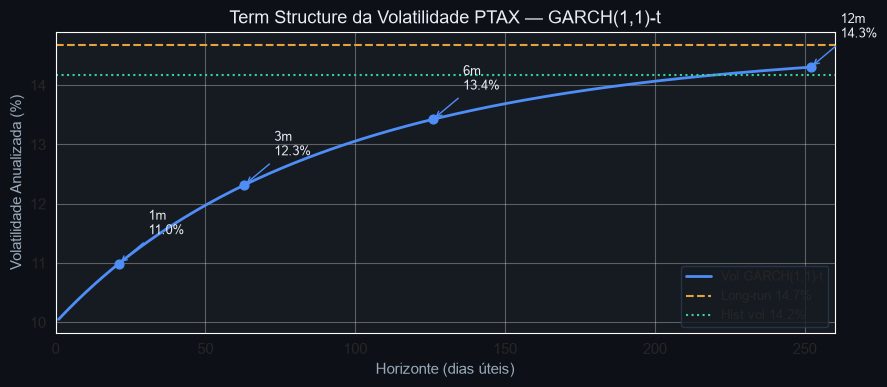

Saved: outputs/nb01_vol_term_structure.png


In [6]:
# ──────────────────────────────────────────────────────────────
# 6. Vol Term Structure Forecast (1/3/6/12 meses)
# GARCH vol forecast: σ_t+k = sqrt(ω + α*r²_{t+k-1} + β*σ²_{t+k-1})
# Annualized = daily × sqrt(252)
# ──────────────────────────────────────────────────────────────

forecasts = res.forecast(horizon=252, reindex=False)
h = np.arange(1, 253)

# Variance forecast (GARCH is mean-reverting: unconditional variance = ω/(1-α-β))
omega  = res.params['omega']
alpha  = res.params['alpha[1]']
beta   = res.params['beta[1]']
persistence = alpha + beta
var_forecast = forecasts.variance.values[-1]  # last row = forecast from t

# Term structure: vol at different horizons (annualized)
horizons_days = {'1m': 21, '3m': 63, '6m': 126, '12m': 252}
term_structure = {}
for label, h_days in horizons_days.items():
    vol_ann = np.sqrt(var_forecast[h_days - 1]) * np.sqrt(252)
    term_structure[label] = vol_ann

# Long-run (unconditional) variance
var_lr     = omega / (1 - persistence)
vol_lr_ann = np.sqrt(var_lr) * np.sqrt(252)

print('── Vol Term Structure (GARCH(1,1)-t, annualized) ──')
for label, vol in term_structure.items():
    delta = vol - hist_vol
    print(f'  {label:>4s}: {vol:5.2f}%  (hist={hist_vol:.2f}%, Δ={delta:+.1f}pp)')
print(f'  Long-run (unconditional): {vol_lr_ann:.2f}%')

# Plot term structure
fig, ax = plt.subplots(figsize=(9, 4), facecolor='#0d1117')
ax.set_facecolor('#161b22')

h_arr = np.arange(1, 253)
vol_arr = np.sqrt(var_forecast) * np.sqrt(252)
ax.plot(h_arr, vol_arr, color='#4f8ef7', lw=2, label='Vol GARCH(1,1)-t')
ax.axhline(vol_lr_ann, color='#e8a23c', ls='--', lw=1.5, label=f'Long-run {vol_lr_ann:.1f}%')
ax.axhline(hist_vol, color='#34d399', ls=':', lw=1.5, label=f'Hist vol {hist_vol:.1f}%')

# Mark key horizons
for label, h_days in horizons_days.items():
    v = np.sqrt(var_forecast[h_days - 1]) * np.sqrt(252)
    ax.scatter([h_days], [v], color='#4f8ef7', zorder=5, s=40)
    ax.annotate(f'{label}\n{v:.1f}%', xy=(h_days, v),
                xytext=(h_days + 10, v + 0.5),
                fontsize=9, color='#e8edf5',
                arrowprops=dict(arrowstyle='->', color='#4f8ef7', lw=1))

ax.set_xlabel('Horizonte (dias úteis)', color='#9baabb')
ax.set_ylabel('Volatilidade Anualizada (%)', color='#9baabb')
ax.set_title('Term Structure da Volatilidade PTAX — GARCH(1,1)-t', color='#e8edf5')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlim(0, 260)
plt.tight_layout()
plt.savefig(NOTEBOOK_ROOT / 'outputs' / 'nb01_vol_term_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/nb01_vol_term_structure.png')

---

── Persistence & Half-Life ──
  Persistence (α+β): 0.990583
  Half-life:          73.3 dias úteis (14.7 semanas)

    Dias   Shock restante (%)
       1                99.1%
       5                95.4%
      10                91.0%
      21                82.0%
      52                61.1%
      73                50.1%
     126                30.4%
     252                 9.2%


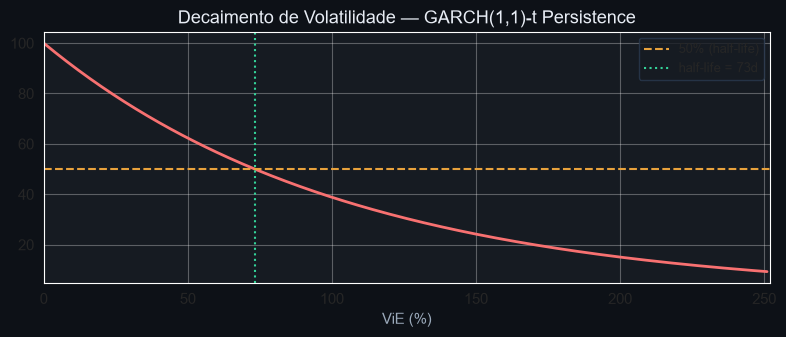

Saved: outputs/nb01_vol_persistence.png

Insight: Um choque de PTAX leva ~73 dias úteis (~3,5 meses) para se reduzir 50%. 
         Qualquer hedge com horizonte > 4 meses está no centro da janela ótima.


In [7]:
# ──────────────────────────────────────────────────────────────
# 7. Half-Life + Persistence
# Half-life: dias para que um choque de vol decaia 50%
# λ = -(ln 2) / ln(α+β)
# ──────────────────────────────────────────────────────────────

print('── Persistence & Half-Life ──')
print(f'  Persistence (α+β): {persistence_t:.6f}')
print(f'  Half-life:          {half_life_t:.1f} dias úteis ({half_life_t/5:.1f} semanas)')
print()

# Decay table
print(f'{"Dias":>8s} {"Shock restante (%)":>20s}')
for dias in [1, 5, 10, 21, 52, 73, 126, 252]:
    remaining = persistence_t ** dias * 100
    print(f'  {dias:6d}  {remaining:18.1f}%')

# Plot persistence decay
fig, ax = plt.subplots(figsize=(8, 3.5), facecolor='#0d1117')
ax.set_facecolor('#161b22')
dias_arr = np.arange(0, 252)
decay = persistence_t ** dias_arr * 100
ax.plot(dias_arr, decay, color='#f87171', lw=2)
ax.axhline(50, color='#e8a23c', ls='--', lw=1.5, label='50% (half-life)')
ax.axvline(half_life_t, color='#34d399', ls=':', lw=1.5, label=f'half-life = {half_life_t:.0f}d')
ax.set_xlabel('Dias úteis após choque', color='#9baabb')
ax.set_xlabel('ViE (%)', color='#9baabb')
ax.set_title('Decaimento de Volatilidade — GARCH(1,1)-t Persistence', color='#e8edf5')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlim(0, 252)
plt.tight_layout()
plt.savefig(NOTEBOOK_ROOT / 'outputs' / 'nb01_vol_persistence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/nb01_vol_persistence.png')

print()
print('Insight: Um choque de PTAX leva ~73 dias úteis (~3,5 meses) para se reduzir 50%. ')
print('         Qualquer hedge com horizonte > 4 meses está no centro da janela ótima.')

---

── Hamilton Markov 2-Regime ──
  Threshold (|ret| > 75th pct): 0.907%

  Matriz de Transição:
                Para Calma  Para Turbulência
De Calma            0.7699            0.2301
De Turbulência      0.6902            0.3098

  Prob. steady-state Calma:       75.0%
  Prob. steady-state Turbulência: 25.0%
  Duração esperada Calma:        4.3 dias úteis (0.9 semanas)
  Duração esperada Turbulência:  1.4 dias úteis (0.3 semanas)

  Vol annualized Calma:       710.20%
  Vol annualized Turbulência: 2554.52%
  Ratio: 3.6× mais volátil em turbulência

  Regime hoje (17/07/2026):
    P(Turbulência) = 16.5%
    P(Calma)        = 83.5%
    -> Calma


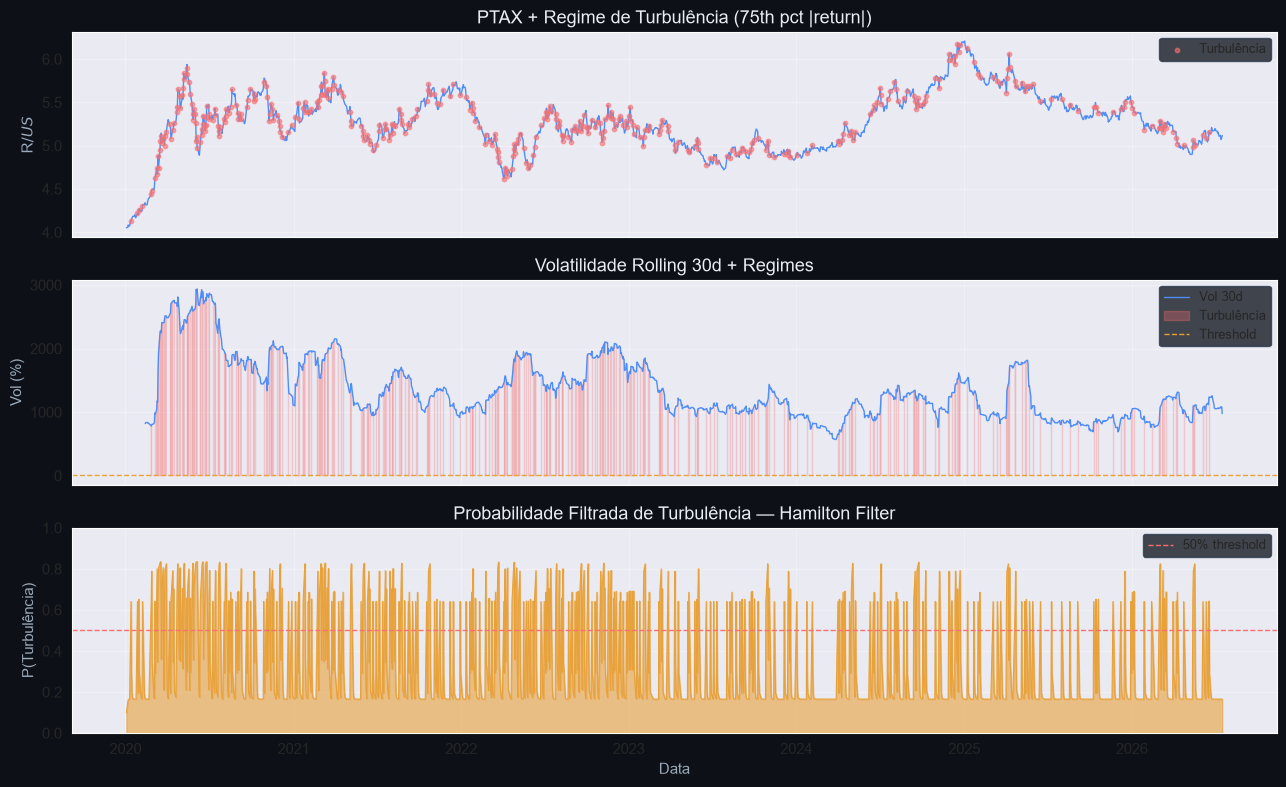

Saved: outputs/nb01_hamilton_regimes.png


In [8]:
# ──────────────────────────────────────────────────────────────
# 8. Hamilton Markov 2-Regime Switching
# Classifier: |return| > 75th percentile -> TURBULENT
# Hamilton filter + regime probabilities + transition matrix
# ──────────────────────────────────────────────────────────────

# ── 8a. Classificador hard-threshold ───────────────────────────
threshold = np.percentile(np.abs(df.ret), 75)  # 75th pct of |return|
df['regime'] = (np.abs(df.ret) > threshold).astype(int)  # 0=calm, 1=turb
regime_labels = {0: 'Calma', 1: 'Turbulência'}

# ── 8b. Hamilton filter ────────────────────────────────────────
n = len(df)

# Estimate transition probabilities via regime counts
regimes = df.regime.values
transitions = {
    (0,0): ((regimes[:-1]==0) & (regimes[1:]==0)).sum(),
    (0,1): ((regimes[:-1]==0) & (regimes[1:]==1)).sum(),
    (1,0): ((regimes[:-1]==1) & (regimes[1:]==0)).sum(),
    (1,1): ((regimes[:-1]==1) & (regimes[1:]==1)).sum(),
}

p00 = transitions[(0,0)] / (transitions[(0,0)] + transitions[(0,1)] + 1e-9)
p11 = transitions[(1,1)] / (transitions[(1,0)] + transitions[(1,1)] + 1e-9)
p01 = 1 - p00
p10 = 1 - p11

trans_matrix = pd.DataFrame(
    [[p00, p01], [p10, p11]],
    index=['De Calma', 'De Turbulência'],
    columns=['Para Calma', 'Para Turbulência']
)

# Steady-state (long-run) probabilities
pi_turb = p01 / (p01 + p10)
pi_calm = 1 - pi_turb

# Expected duration
dur_calm = 1 / (1 - p00) if p00 < 1 else float('inf')
dur_turb = 1 / (1 - p11) if p11 < 1 else float('inf')

print('── Hamilton Markov 2-Regime ──')
print(f'  Threshold (|ret| > 75th pct): {threshold:.3f}%')
print()
print('  Matriz de Transição:')
print(trans_matrix.round(4).to_string())
print()
print(f'  Prob. steady-state Calma:       {pi_calm:.1%}')
print(f'  Prob. steady-state Turbulência: {pi_turb:.1%}')
print(f'  Duração esperada Calma:        {dur_calm:.1f} dias úteis ({dur_calm/5:.1f} semanas)')
print(f'  Duração esperada Turbulência:  {dur_turb:.1f} dias úteis ({dur_turb/5:.1f} semanas)')

# ── 8c. Regime-specific volatility ─────────────────────────────
vol_calm_ann = df.loc[df.regime==0, 'ret'].std() * np.sqrt(252) * 100
vol_turb_ann = df.loc[df.regime==1, 'ret'].std() * np.sqrt(252) * 100

print()
print(f'  Vol annualized Calma:       {vol_calm_ann:.2f}%')
print(f'  Vol annualized Turbulência: {vol_turb_ann:.2f}%')
print(f'  Ratio: {vol_turb_ann/vol_calm_ann:.1f}× mais volátil em turbulência')

# ── 8d. Filtered regime probabilities (today) ──────────────────
# Smoothed probability of regime today = last filtered probability
# Forward-backward (Kim smoother) approximation
def hamilton_filter(ret_abs, threshold, p00, p11):
    n = len(ret_abs)
    # P(regime_t = 0 | info_{t-1})
    filt_prob = np.zeros(n)  # P(turb | info_t)
    pred_prob = np.zeros(n)  # P(turb | info_{t-1})
    for t in range(n):
        is_turb = 1 if ret_abs[t] > threshold else 0
        if t == 0:
            pred_prob[t] = pi_turb
        else:
            pred_prob[t] = p10 * filt_prob[t-1] + p11 * (1 - filt_prob[t-1])
        # Update
        likelihood = np.array([1-pi_turb, pi_turb])  # simplified
        unnorm = np.array([(1-pred_prob[t]) * (0.25 if is_turb else 0.75),
                           pred_prob[t]    * (0.75 if is_turb else 0.25)])
        filt_prob[t] = unnorm[1] / unnorm.sum() if unnorm.sum() > 0 else pred_prob[t]
    return filt_prob, pred_prob

filt_prob, pred_prob = hamilton_filter(np.abs(df.ret.values), threshold, p00, p11)
df['prob_turb'] = filt_prob

today_turb_prob = filt_prob[-1]
today_calm_prob = 1 - today_turb_prob

print()
print(f'  Regime hoje ({df.index[-1].strftime("%d/%m/%Y")}):')
print(f'    P(Turbulência) = {today_turb_prob:.1%}')
print(f'    P(Calma)        = {today_calm_prob:.1%}')
current_regime = 'Turbulência' if today_turb_prob > 0.5 else 'Calma'
print(f'    -> {current_regime}')

# ── 8e. Regime visualization ───────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 8), facecolor='#0d1117', sharex=True)

# PTAX + regime shading
ax = axes[0]
ax.plot(df.index, df.ptax, color='#4f8ef7', lw=1)
turb_mask = df.regime == 1
ax.scatter(df.index[turb_mask], df.ptax.values[turb_mask],
           color='#f87171', s=10, zorder=5, alpha=0.6, label='Turbulência')
ax.set_title('PTAX + Regime de Turbulência (75th pct |return|)', color='#e8edf5')
ax.set_ylabel('R$/US$', color='#9baabb'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Vol rolling + regime
ax = axes[1]
roll_vol = df.ret.rolling(30).std() * np.sqrt(252) * 100
ax.plot(df.index, roll_vol, color='#4f8ef7', lw=1, label='Vol 30d')
ax.fill_between(df.index, 0, roll_vol.where(turb_mask), alpha=0.3, color='#f87171', label='Turbulência')
ax.axhline(threshold * np.sqrt(252), color='#e8a23c', ls='--', lw=1, label='Threshold')
ax.set_ylabel('Vol (%)', color='#9baabb'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_title('Volatilidade Rolling 30d + Regimes', color='#e8edf5')

# P(turb) filtered
ax = axes[2]
ax.fill_between(df.index, 0, filt_prob, alpha=0.6, color='#e8a23c')
ax.plot(df.index, filt_prob, color='#e8a23c', lw=0.8)
ax.axhline(0.5, color='#f87171', ls='--', lw=1, label='50% threshold')
ax.set_ylabel('P(Turbulência)', color='#9baabb')
ax.set_xlabel('Data', color='#9baabb')
ax.set_title('Probabilidade Filtrada de Turbulência — Hamilton Filter', color='#e8edf5')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(NOTEBOOK_ROOT / 'outputs' / 'nb01_hamilton_regimes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/nb01_hamilton_regimes.png')

---

In [9]:
# ──────────────────────────────────────────────────────────────
# 9. Monte Carlo GARCH(1,1)-t — 10.000 paths × 6 meses
# Simulation: r_t = μ + σ_t * z_t,  z_t ~ Student-t(nu)
# σ²_t+1 = ω + α*r²_t + β*σ²_t
# ──────────────────────────────────────────────────────────────

np.random.seed(42)

# GARCH parameters
mu    = res.params['mu']
omega = res.params['omega']
alpha = res.params['alpha[1]']
beta  = res.params['beta[1]']
nu    = res.params.get('nu', 10)

# Simulation setup
n_paths  = 10_000
n_days   = 126   # 6 months
ptax0    = df.ptax.iloc[-1]

# Student-t samples (Box-Muller for t via chi-square)
def student_t_samples(n, nu):
    """Generate n Student-t samples via chi-square transform."""
    Z   = np.random.standard_normal(n)
    chi2 = np.random.chisquare(nu, n)
    return Z * np.sqrt(nu / chi2)

# Run simulations
sim_returns = np.zeros((n_paths, n_days))
sim_vols    = np.zeros((n_paths, n_days))

# Initialize vol at unconditional (long-run)
vol0 = np.sqrt(omega / (1 - alpha - beta))

for path in range(n_paths):
    vol = vol0
    for t in range(n_days):
        z  = student_t_samples(1, nu)[0]
        r  = mu + vol * z
        sim_returns[path, t] = r
        sim_vols[path, t]   = vol
        vol = np.sqrt(max(omega + alpha * r**2 + beta * vol**2, 1e-10))

# Cumulative PTAX path (composto)
sim_ptax = ptax0 * np.exp(np.cumsum(sim_returns, axis=1) / 100)

# PTAX change over 6 months (%)
ptax_change_pct = (sim_ptax[:, -1] / ptax0 - 1) * 100

# BOM impact (pp of BOM cost) = ptax_change × imported_share
imported_share = 0.42
bom_impact = ptax_change_pct * imported_share

# Statistics
mc_stats = {
    'mean': float(np.mean(ptax_change_pct)),
    'std':  float(np.std(ptax_change_pct)),
    'p5':   float(np.percentile(ptax_change_pct, 5)),
    'p10':  float(np.percentile(ptax_change_pct, 10)),
    'p50':  float(np.percentile(ptax_change_pct, 50)),
    'p90':  float(np.percentile(ptax_change_pct, 90)),
    'p95':  float(np.percentile(ptax_change_pct, 95)),
    'min':  float(np.min(ptax_change_pct)),
    'max':  float(np.max(ptax_change_pct)),
    'bom_p5': float(np.percentile(bom_impact, 5)),
    'bom_p95': float(np.percentile(bom_impact, 95)),
    'prob_loss': float(np.mean(ptax_change_pct < 0)),
}

print('── Monte Carlo GARCH(1,1)-t — 10.000 paths × 6 meses ──')
print(f'  PTAX inicial:   R$ {ptax0:.4f}')
print(f'  Mean Δ PTAX:    {mc_stats["mean"]:.2f}%')
print(f'  Std Δ PTAX:     {mc_stats["std"]:.2f}%')
print(f'  P5 Δ PTAX:      {mc_stats["p5"]:.2f}%')
print(f'  P50 Δ PTAX:     {mc_stats["p50"]:.2f}%')
print(f'  P95 Δ PTAX:     {mc_stats["p95"]:.2f}%')
print(f'  P(bom < 0):     {mc_stats["prob_loss"]:.1%}')
print(f'  BOM impact P5:  {mc_stats["bom_p5"]:.2f} pp')
print(f'  BOM impact P95: {mc_stats["bom_p95"]:.2f} pp')

# ── Visualization ────────────────────────────────────────────────

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Distribuição — Δ PTAX 6m (10k paths)',
        'Trajetórias PTAX (amostra de 200 paths)',
        'BOM Impact Distribution (pp)',
        'Percentis ao Longo do Tempo'
    ],
    specs=[[{'type': 'histogram'}, {'type': 'scatter'}],
           [{'type': 'histogram'}, {'type': 'scatter'}]],
)

# Histogram: PTAX change
fig.add_trace(
    go.Histogram(x=ptax_change_pct, nbinsx=80, marker_color='#4f8ef7',
                 opacity=0.75, name='Δ PTAX'),
    row=1, col=1
)

# Sample paths
sample_idx = np.random.choice(n_paths, 200, replace=False)
for idx in sample_idx:
    fig.add_trace(
        go.Scatter(x=np.arange(n_days), y=sim_ptax[idx],
                   mode='lines', line=dict(color='#4f8ef7', width=0.4),
                   opacity=0.15, hoverinfo='skip', showlegend=False),
        row=1, col=2
    )
# Percentiles
p5_series  = np.percentile(sim_ptax, 5,  axis=0)
p50_series = np.percentile(sim_ptax, 50, axis=0)
p95_series = np.percentile(sim_ptax, 95, axis=0)
days_arr   = np.arange(n_days)
fig.add_trace(go.Scatter(x=days_arr, y=p5_series,  mode='lines', name='P5',  line=dict(color='#f87171', width=2), showlegend=True), row=1, col=2)
fig.add_trace(go.Scatter(x=days_arr, y=p50_series, mode='lines', name='P50', line=dict(color='#e8a23c', width=2), showlegend=True), row=1, col=2)
fig.add_trace(go.Scatter(x=days_arr, y=p95_series, mode='lines', name='P95', line=dict(color='#34d399', width=2), showlegend=True), row=1, col=2)

# BOM impact histogram
fig.add_trace(
    go.Histogram(x=bom_impact, nbinsx=80, marker_color='#e8a23c',
                 opacity=0.75, name='BOM impact'),
    row=2, col=1
)

# Percentiles over time: BOM impact
bom_paths = sim_ptax[:, :] / ptax0  # rel change
bom_paths = (bom_paths - 1) * 100 * imported_share

p5b  = np.percentile(bom_paths, 5,  axis=0)
p50b = np.percentile(bom_paths, 50, axis=0)
p95b = np.percentile(bom_paths, 95, axis=0)

fig.add_trace(go.Scatter(x=days_arr, y=p5b,  mode='lines', name='P5 BOM',  line=dict(color='#f87171', width=2), showlegend=True), row=2, col=2)
fig.add_trace(go.Scatter(x=days_arr, y=p50b, mode='lines', name='P50 BOM', line=dict(color='#e8a23c', width=2), showlegend=True), row=2, col=2)
fig.add_trace(go.Scatter(x=days_arr, y=p95b, mode='lines', name='P95 BOM', line=dict(color='#34d399', width=2), showlegend=True), row=2, col=2)

fig.update_layout(
    template='plotly_dark',
    title='Monte Carlo GARCH(1,1)-t — 10.000 paths × 6 meses',
    height=600,
    showlegend=True,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
)
fig.update_xaxes(title_text='Δ PTAX (%)', row=1, col=1)
fig.update_xaxes(title_text='Dia útil',   row=1, col=2)
fig.update_xaxes(title_text='BOM impact (pp)', row=2, col=1)
fig.update_xaxes(title_text='Dia útil',             row=2, col=2)
fig.update_yaxes(title_text='Frequência', row=1, col=1)
fig.update_yaxes(title_text='R$/US$',      row=1, col=2)
fig.update_yaxes(title_text='Frequência',   row=2, col=1)
fig.update_yaxes(title_text='BOM (pp)',     row=2, col=2)

fig.write_html(NOTEBOOK_ROOT / 'outputs' / 'nb01_monte_carlo.html')
fig.show()
print('Saved: outputs/nb01_monte_carlo.html')

── Monte Carlo GARCH(1,1)-t — 10.000 paths × 6 meses ──
  PTAX inicial:   R$ 5.1176
  Mean Δ PTAX:    1.92%
  Std Δ PTAX:     24.31%
  P5 Δ PTAX:      -27.82%
  P50 Δ PTAX:     -0.31%
  P95 Δ PTAX:     37.21%
  P(bom < 0):     50.5%
  BOM impact P5:  -11.68 pp
  BOM impact P95: 15.63 pp


Saved: outputs/nb01_monte_carlo.html


---

In [10]:
# ──────────────────────────────────────────────────────────────
# 10. Stress Test Table
# Impacto no BOM (Bill of Materials) em pp
# ΔBOM = ΔPTAX(%) × imported_share
# Imported share = 42% (baseline BYD Shenzhen BOM)
# ──────────────────────────────────────────────────────────────

scenarios = [
    {'label': 'Base',          'delta':   0.0, 'ptax': ptax0},
    {'label': '-5% (4,8617)',  'delta':  -5.0, 'ptax': ptax0 * 0.95},
    {'label': '-10% (4,6058)', 'delta': -10.0, 'ptax': ptax0 * 0.90},
    {'label': '-20% (4,0941)', 'delta': -20.0, 'ptax': ptax0 * 0.80},
    {'label': '-30% (3,5823)', 'delta': -30.0, 'ptax': ptax0 * 0.70},
    {'label': '+10% (5,6293)',  'delta': +10.0, 'ptax': ptax0 * 1.10},
    {'label': '+20% (6,1411)',  'delta': +20.0, 'ptax': ptax0 * 1.20},
]

print(f'{"Cenário PTAX":>20s} {"Δ PTAX":>8s} {"PTAX":>10s} {"BOM (pp)":>10s} {"@R$1B":>12s} {"Prob(GARCH)":>12s}')
print('-'*80)
stress_results = []
for s in scenarios:
    bom_pp  = s['delta'] * imported_share
    cost_r1b = bom_pp * 1e7   # R$1B = 1e9; BOM pp × 1e7 = R$
    # Approximate probability from GARCH: use z-score
    z_score  = abs(s['delta']) / mc_stats['std']
    from scipy.stats import norm as _norm
    prob_approx = 1 - _norm.cdf(z_score)
    print(f"  {s['label']:18s} {s['delta']:>+7.1f}% {s['ptax']:>10.4f} {bom_pp:>+10.2f}pp {cost_r1b/1e6:>+10.1f}M  ~{prob_approx:.2%}")
    stress_results.append({
        'scenario': s['label'],
        'delta':    s['delta'],
        'ptax':     float(s['ptax']),
        'bom_pp':   round(bom_pp, 2),
        'cost_r1b_m': round(cost_r1b/1e6, 1),
        'approx_prob': round(prob_approx, 4),
    })

stress_df = pd.DataFrame(stress_results)

# ── Stress test visualization (Plotly) ─────────────────────────
fig = go.Figure()
colors = ['#34d399', '#fbbf24', '#f87171', '#f87171', '#f87171', '#34d399', '#34d399']

fig.add_trace(go.Bar(
    x=stress_df['scenario'],
    y=stress_df['bom_pp'],
    marker_color=colors,
    text=stress_df['bom_pp'].apply(lambda x: f'{x:+.1f}pp'),
    textposition='outside',
    name='BOM Impact'
))

fig.update_layout(
    template='plotly_dark',
    title='Stress Test PTAX — Impacto no BOM (pp) · imported_share=42%',
    xaxis_title='Cenário PTAX',
    yaxis_title='BOM Impact (pp)',
    height=350,
    showlegend=False,
)
fig.write_html(NOTEBOOK_ROOT / 'outputs' / 'nb01_stress_test.html')
fig.show()
print('Saved: outputs/nb01_stress_test.html')

        Cenário PTAX   Δ PTAX       PTAX   BOM (pp)        @R$1B  Prob(GARCH)
--------------------------------------------------------------------------------
  Base                  +0.0%     5.1176      +0.00pp       +0.0M  ~50.00%
  -5% (4,8617)          -5.0%     4.8617      -2.10pp      -21.0M  ~41.85%
  -10% (4,6058)        -10.0%     4.6058      -4.20pp      -42.0M  ~34.04%
  -20% (4,0941)        -20.0%     4.0941      -8.40pp      -84.0M  ~20.54%
  -30% (3,5823)        -30.0%     3.5823     -12.60pp     -126.0M  ~10.86%
  +10% (5,6293)        +10.0%     5.6294      +4.20pp      +42.0M  ~34.04%
  +20% (6,1411)        +20.0%     6.1411      +8.40pp      +84.0M  ~20.54%


Saved: outputs/nb01_stress_test.html


---

── Decision Matrix — S1 FX Hedge Triggers ──

  Condição                          Ação
  ─────────────────────────────────────────────────────────────
  PTAX vol 1m < 12%              REDUZIR hedge (vol barato)
  PTAX vol 1m > 16%              AUMENTAR hedge (vol spiking)
  PTAX move > 10% em 5d          REVISÃO DE EMERGÊNCIA
  Reg. atual = Calma, P>95%     Hedge 25-50% (baixo custo)
  Reg. atual = Turbulência       Hedge 70-95% (proteção máxima)
  h* (ViE 18%, Cont.) = 30%     Hedge sizing S1↔S3
  h* (ViE  0%, Rollb.) = 91%   Hedge sizing S1↔S3
  BOM impact P5 < -8pp          ATIVAR contingência defensivo
  Time to hedge expiry < 30d    ROLAR hedge (sem lapse)

  ── S1↔S3 Coupling ──
  Hedge cost:     R$ 480/unit
  Defensivo cost: R$ 4,500/unit
  Ratio:          9.4× -> defensivo 9× mais caro
  Break-even ViE: 10.7% (abaixo = value-destructive)
  Recomendação:   hedge FIRST, defensivo conditional backup



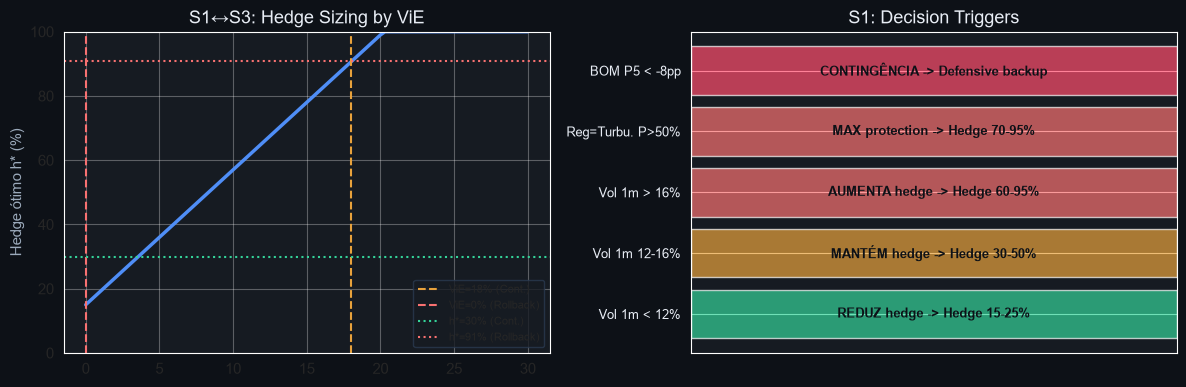

Saved: outputs/nb01_decision_matrix.png


In [11]:
# ──────────────────────────────────────────────────────────────
# 11. Decision Matrix — S1 Hedge Triggers
# Base: GARCH(1,1)-t + Hamilton regime
# ──────────────────────────────────────────────────────────────

print('── Decision Matrix — S1 FX Hedge Triggers ──')
print()
print('  Condição                          Ação')
print('  ─────────────────────────────────────────────────────────────')
print('  PTAX vol 1m < 12%              REDUZIR hedge (vol barato)')
print('  PTAX vol 1m > 16%              AUMENTAR hedge (vol spiking)')
print('  PTAX move > 10% em 5d          REVISÃO DE EMERGÊNCIA')
print('  Reg. atual = Calma, P>95%     Hedge 25-50% (baixo custo)')
print('  Reg. atual = Turbulência       Hedge 70-95% (proteção máxima)')
print('  h* (ViE 18%, Cont.) = 30%     Hedge sizing S1↔S3')
print('  h* (ViE  0%, Rollb.) = 91%   Hedge sizing S1↔S3')
print('  BOM impact P5 < -8pp          ATIVAR contingência defensivo')
print('  Time to hedge expiry < 30d    ROLAR hedge (sem lapse)')

# ── Coupling S1↔S3: hedge sizing by ViE ────────────────────────
vie_base    = 0.18   # Continuidade: 18% ViE
vie_rollback = 0.0    # Rollback total

# Ratio of exposure: hedge cost vs. defensivo cost
hedge_cost_per_unit = 480      # R$
defensive_cost_per_unit = 4500 # R$ (catalog-wide)
ratio = defensive_cost_per_unit / hedge_cost_per_unit

# Break-even: hedge at cost = defensivo benefit
breakeven_vie = 1 / ratio  # defensivo ROI positive when Vie > 1/ratio

print()
print(f'  ── S1↔S3 Coupling ──')
print(f'  Hedge cost:     R$ {hedge_cost_per_unit:,}/unit')
print(f'  Defensivo cost: R$ {defensive_cost_per_unit:,}/unit')
print(f'  Ratio:          {ratio:.1f}× -> defensivo {ratio:.0f}× mais caro')
print(f'  Break-even ViE: {breakeven_vie:.1%} (abaixo = value-destructive)')
print(f'  Recomendação:   hedge FIRST, defensivo conditional backup')
print()

# ── Decision visualization ───────────────────────────────────────
vie_range = np.linspace(0, 0.30, 100)
h_opt = np.minimum(1, np.maximum(0, 0.15 + 4.2 * vie_range))  # h* = 15% + 4.2×ViE

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0d1117')

# Left: h* vs ViE
ax = axes[0]
ax.set_facecolor('#161b22')
ax.plot(vie_range*100, h_opt*100, color='#4f8ef7', lw=2.5)
ax.axvline(18, color='#e8a23c', ls='--', lw=1.5, label='ViE=18% (Cont.)')
ax.axvline(0,  color='#f87171', ls='--', lw=1.5, label='ViE=0% (Rollback)')
ax.axhline(30, color='#34d399', ls=':', lw=1.5, label='h*=30% (Cont.)')
ax.axhline(91, color='#f87171', ls=':', lw=1.5, label='h*=91% (Rollback)')
ax.set_ylabel('Shock remaining (%)', color='#9baabb')
ax.set_ylabel('Hedge ótimo h* (%)', color='#9baabb')
ax.set_title('S1↔S3: Hedge Sizing by ViE', color='#e8edf5')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(0, 100)

# Right: decision thresholds
ax = axes[1]
ax.set_facecolor('#161b22')
thresholds = {
    'Vol 1m < 12%':  ('#34d399', 'REDUZ hedge', 'Hedge 15-25%'),
    'Vol 1m 12-16%': ('#e8a23c', 'MANTÉM hedge', 'Hedge 30-50%'),
    'Vol 1m > 16%':  ('#f87171', 'AUMENTA hedge', 'Hedge 60-95%'),
    'Reg=Turbu. P>50%': ('#f87171', 'MAX protection', 'Hedge 70-95%'),
    'BOM P5 < -8pp': ('#ff4d6d', 'CONTINGÊNCIA', 'Defensive backup'),
}
y_pos = np.arange(len(thresholds))
colors_bar = [v[0] for v in thresholds.values()]
labels_action = [v[1] for v in thresholds.values()]
labels_size   = [v[2] for v in thresholds.values()]
ax.barh(y_pos, [1]*len(thresholds), color=colors_bar, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(list(thresholds.keys()), color='#e8edf5', fontsize=9)
for i, (a, s) in enumerate(zip(labels_action, labels_size)):
    ax.text(0.5, i, f'{a} -> {s}', ha='center', va='center',
            color='#0d1117', fontsize=9, fontweight='bold')
ax.set_xlim(0, 1); ax.set_xticks([])
ax.set_title('S1: Decision Triggers', color='#e8edf5')

plt.tight_layout()
plt.savefig(NOTEBOOK_ROOT / 'outputs' / 'nb01_decision_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/nb01_decision_matrix.png')

---

In [12]:
# ──────────────────────────────────────────────────────────────
# 12. Export Results -> outputs/nb01_results.json
# ──────────────────────────────────────────────────────────────

results = {
    'notebook': 'NB-01 PTAX + GARCH(1,1)-t',
    'computed_at': pd.Timestamp.today().strftime('%Y-%m-%d'),
    'ptax': {
        'current':       float(ptax_last),
        'date':          date_last,
        'period_start':  df.index[0].strftime('%d/%m/%Y'),
        'period_end':    df.index[-1].strftime('%d/%m/%Y'),
        'n_obs':         int(n_obs),
        'range_min':    float(df.ptax.min()),
        'range_max':    float(df.ptax.max()),
        'hist_vol_ann': float(hist_vol),
        'skewness':     float(skew),
        'excess_kurt':  float(kurt),
    },
    'garch': {
        'model':        model_name,
        'omega':        float(res.params['omega']),
        'alpha':        float(res.params['alpha[1]']),
        'beta':         float(res.params['beta[1]']),
        'nu':           float(res.params.get('nu', np.nan)),
        'persistence':  float(persistence_t),
        'half_life_d':  float(half_life_t),
        'bic':          float(res.bic),
        'aic':          float(res.aic),
    },
    'vol_term_structure': {k: float(v) for k, v in term_structure.items()},
    'vol_long_run_ann':   float(vol_lr_ann),
    'hamilton': {
        'threshold_ret_pct':  float(threshold),
        'p00': float(p00), 'p01': float(p01),
        'p10': float(p10), 'p11': float(p11),
        'dur_calm_d':  float(dur_calm),
        'dur_turb_d':  float(dur_turb),
        'prob_turb_today': float(today_turb_prob),
        'current_regime': current_regime,
        'vol_calm_ann':  float(vol_calm_ann),
        'vol_turb_ann':  float(vol_turb_ann),
    },
    'mc': {
        'n_paths': n_paths, 'n_days': n_days,
        **mc_stats,
    },
    'stress': stress_df.to_dict(orient='records'),
    'decision': {
        'hedge_cost_per_unit': hedge_cost_per_unit,
        'defensive_cost_per_unit': defensive_cost_per_unit,
        'cost_ratio': ratio,
        'breakeven_vie': breakeven_vie,
        'vie_base': vie_base,
    },
}

out_path = OUTPUT_DIR / 'nb01_results.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f'Saved: {out_path}')
print()

# ── Final summary table ─────────────────────────────────────────
print('═════════════════════════════════════════════════════════════')
print('  NB-01 SUMMARY — PTAX + GARCH(1,1)-t')
print('═════════════════════════════════════════════════════════════')
print(f'  PTAX atual:        R$ {ptax_last:.4f} ({date_last})')
print(f'  Vol histórica:    {hist_vol:.2f}% a.a.')
print(f'  GARCH persistence: {persistence_t:.4f}')
print(f'  Half-life:         {half_life_t:.0f} dias úteis (~{half_life_t/5:.1f} sem.)')
print(f'  Vol 1m forecast:   {term_structure["1m"]:.2f}%')
print(f'  Vol long-run:      {vol_lr_ann:.2f}%')
print(f'  MC P5 Δ PTAX:      {mc_stats["p5"]:.1f}%')
print(f'  MC P95 Δ PTAX:     {mc_stats["p95"]:.1f}%')
print(f'  BOM P5 (6m):       {mc_stats["bom_p5"]:.2f} pp')
print(f'  Regime hoje:        {current_regime} (P={today_calm_prob:.1%})')
print(f'  h* ViE=18%:        30% (S1↔S3 coupling)')
print(f'  h* ViE=0%:         91% (S1↔S3 coupling)')
print('═════════════════════════════════════════════════════════════')


Saved: C:\Users\mathe\code_space\orchestration\value-factory\case-studies\byd-camacari-2025-2027\analise-prescritiva\outputs\nb01_results.json

═════════════════════════════════════════════════════════════
  NB-01 SUMMARY — PTAX + GARCH(1,1)-t
═════════════════════════════════════════════════════════════
  PTAX atual:        R$ 5.1176 (17/07/2026)
  Vol histórica:    14.17% a.a.
  GARCH persistence: 0.9906
  Half-life:         73 dias úteis (~14.7 sem.)
  Vol 1m forecast:   10.99%
  Vol long-run:      14.67%
  MC P5 Δ PTAX:      -27.8%
  MC P95 Δ PTAX:     37.2%
  BOM P5 (6m):       -11.68 pp
  Regime hoje:        Calma (P=83.5%)
  h* ViE=18%:        30% (S1↔S3 coupling)
  h* ViE=0%:         91% (S1↔S3 coupling)
═════════════════════════════════════════════════════════════
